# Análisis de diversidad microbiana en ecosistemas de agua subterránea

**Fuente de datos:** ENIGMA Study — Zenodo, DOI: 10.5281/zenodo.1455792 — tabla de OTUs (16S rRNA V4) y metadatos ambientales de 67 pozos de agua subterránea.

## 1. Introducción

Los pozos de agua subterránea albergan comunidades bacterianas cuya composición varía según las condiciones fisicoquímicas del ambiente que habitan, tales como el pH, la presencia de metales y la conductividad eléctrica del agua. Este proyecto analiza la diversidad bacteriana de 67 pozos del estudio ENIGMA mediante secuenciación 16S rRNA (región V4), con el propósito de identificar patrones de diversidad microbiana y su asociación con variables ambientales, transformando datos crudos de secuenciación en indicadores cuantitativos, visualizaciones interpretables y análisis estadísticos reproducibles en Python.

## 2. Planteamiento del problema

Los pozos de agua subterránea contienen comunidades bacterianas diversas que cambian según el ambiente (pH, metales, conductividad). El problema es que no existe un análisis claro y reproducible que ayude a los investigadores a entender cuáles de estas variables tienen más impacto en la diversidad bacteriana.

Este proyecto toma los datos del estudio ENIGMA (67 pozos, secuenciación 16S rRNA V4) y los convierte en indicadores de diversidad, gráficas interpretables y correlaciones estadísticas, con el objetivo de apoyar decisiones de monitoreo.

## 3. Pregunta analítica

| No. | Pregunta | Variable relacionada |
|---:|---|---|
| 1 | ¿Cuántas especies bacterianas (OTUs) hay en promedio por pozo? | Riqueza de OTUs por muestra |
| 2 | ¿Qué pozos tienen mayor y menor diversidad bacteriana según Shannon? | Índice de Shannon (H') por pozo |
| 3 | ¿Hay grupos de pozos con composición bacteriana similar? | Distancia Bray-Curtis + PCoA |
| 4 | ¿Las variables ambientales se relacionan con la diversidad (Shannon)? | Correlación de Spearman: variables ambientales vs. H' |
| 5 | ¿Qué bacterias (OTUs) dominan y están presentes en más pozos? | Abundancia relativa por OTU |
| 6 | ¿Los metales pesados se asocian con menor diversidad? | Correlación de Spearman: metales vs. diversidad |

La pregunta analítica principal que orienta el proyecto es: **¿qué variables ambientales se asocian más fuertemente con la diversidad bacteriana (Shannon) entre los 67 pozos?**

## 4. Objetivo general

Analizar la diversidad bacteriana (16S rRNA V4) en 67 pozos de agua subterránea del estudio ENIGMA usando Python, para identificar patrones de diversidad y su asociación con variables ambientales.

### Objetivos específicos

1. Explorar la abundancia y distribución de bacterias (OTUs) en cada pozo.
2. Calcular métricas de diversidad alfa: riqueza, Shannon, Simpson y Chao1.
3. Analizar las diferencias entre muestras (diversidad beta) con la distancia de Bray-Curtis y visualizarlo en PCoA.
4. Evaluar si las variables ambientales se relacionan estadísticamente con la diversidad bacteriana (correlación de Spearman).

## 5. Usuarios del análisis

| Elemento | Respuesta |
|---|---|
| Usuario final del análisis | Investigadores en microbiología ambiental y gestores de recursos hídricos subterráneos |
| Decisión que se desea apoyar | Identificar qué factores ambientales afectan la diversidad microbiana en pozos de agua subterránea, para priorizar sitios de monitoreo |

## 6. Descripción del dataset

| Elemento | Respuesta |
|---|---|
| Tipo de datos disponibles | Tabla de OTUs (abundancias de bacterias 16S rRNA V4) + metadatos ambientales (pH, metales, conductividad, gases disueltos, entre otros) |
| Fuente de los datos | ENIGMA Study — Zenodo — https://zenodo.org/records/1455793 |

### Diccionario de datos

**Dataset 1: OTU Table (`otu_table_resampled_updated_r.txt`)**

| Variable | Tipo | Descripción | Uso en el proyecto |
|---|---|---|---|
| Index (OTU_ID) | str | Identificador único de cada bacteria (OTU) | Clave para calcular riqueza y abundancia |
| Columnas de muestras (ej. `EW.B002`) | int/float | Número de lecturas del OTU en ese pozo tras rarefacción | Variable principal para calcular diversidad alfa y beta |

**Dataset 2: Metadata (`enigma.metadata.txt`)**

| Variable | Tipo | Descripción | Uso en el proyecto |
|---|---|---|---|
| SampleID | str | Identificador del pozo (ej. `EW.B002`) | Clave para unir OTU table con metadatos |
| pH | float | pH del agua del pozo | Variable ambiental: correlación con diversidad |
| Fe | float | Concentración de hierro (mg/L) | Variable de contaminación metálica |
| Mn | float | Concentración de manganeso (mg/L) | Variable de contaminación metálica |
| U | float | Concentración de uranio (µg/L) | Variable de contaminación radiactiva |
| Conductivity | float | Conductividad eléctrica (µS/cm) | Indicador de mineralización del agua |
| Temperature | float | Temperatura del agua (°C) | Variable ambiental física |
| (otras 30+ variables) | float | Metales, aniones, gases disueltos y profundidad del pozo | Evaluadas en el análisis de correlación con Shannon (sección 12)|

## 7. Carga de datos

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from IPython.display import display

try:
    import plotly.express  # noqa: F401 -- solo para verificar disponibilidad
    PLOTLY_DISPONIBLE = True
except ImportError:
    PLOTLY_DISPONIBLE = False

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Librerías cargadas correctamente.')
print('Plotly disponible:', PLOTLY_DISPONIBLE)

Librerías cargadas correctamente.
Plotly disponible: True


In [2]:
ARCHIVO_METADATA = 'enigma.metadata.txt'
ARCHIVO_OTU = 'otu_table_resampled_updated_r.txt'

print('Archivo metadata existe:', os.path.exists(ARCHIVO_METADATA))
print('Archivo OTU existe:', os.path.exists(ARCHIVO_OTU))

Archivo metadata existe: True
Archivo OTU existe: True


In [3]:
# Carga de los datasets
meta = pd.read_csv(ARCHIVO_METADATA, sep='\t', index_col=0)
otu = pd.read_csv(ARCHIVO_OTU, sep='\t', index_col=0)

# Filtrar solo las muestras del tamaño de poro 0.02 µm (fracción bacteriana)
meta_02 = meta[meta.index.astype(str).str.endswith('02')].copy()
meta_02.index = meta_02.index.astype(str).str[:-3].str.replace('_', '.')

# Alinear muestras entre OTU y metadata
muestras_comunes = [m for m in meta_02.index if m in otu.columns]
otu_filt = otu[muestras_comunes].copy()
meta_filt = meta_02.loc[muestras_comunes].copy()
otu_filt = otu_filt.loc[otu_filt.sum(axis=1) > 0]

print(f'Muestras (pozos): {len(muestras_comunes)}')
print(f'OTUs con lecturas: {otu_filt.shape[0]}')
print(f'Variables ambientales: {meta_filt.shape[1]}')
otu_filt.head(3)

Muestras (pozos): 67
OTUs con lecturas: 16236
Variables ambientales: 58


,DP16D.67.11.27.12,FW021.46.11.27.12,FW021.7.26.12,FW104.67.11.14.12,FW104.7.26.12,FW106.11.13.12,FW106.7.25.12,FW109.2.7.25.12,FW109.35.61.11.14.12,FW109.40.92.11.14.12,FW126.7.25.12,FW215.84.11.27..12,FW233.2.17.99.11.28.12,FW300.59.10.19.12,FW301.7.25.12,FW301.81.10.19.12,FW301.81.2.20.13,FW303.11.10.23.12,FW303.11.2.20.13,FW410.28.46.11.13.12,FW510.26.11.26.12,FW511.61.11.26.12,FW511.7.26.13,FW602.2.26.2.11.28.12,FW603.55.12.3.12,GW056.87.1.8.13,GW057.10.1.8.13,GW066.71.2.20.13,GW084.56.11.28.12,GW085.58.12.3.12,GW086.25.12.3.12,GW089.62.1.7.13,GW098.57.1.22.13,GW101.11.13.12,GW101.7.25.12,GW105.12.11.12,GW107.91.12.11.12,GW115.2.11.26.12,GW122.78.11.14.12,GW123.93.11.14.12,GW125.85.2.20.13,GW127.16.11.26.12,GW148.12.17.12,GW151.12.12.12,GW162.37.2.19.13,GW190.22.12.11.12,GW198.41.2.11.13,GW199.42.1.28.13,GW220.50.12.12.12,GW223.39.1.8.13,GW228.12.2.4.13,GW246.1.11.26.12,GW247.7.11.14.12,GW271.66.2.18.13,GW283.43.1.29.13,GW314.97.2.19.13,GW345.51.11.27.12,GW346.47.11.27.12,GW350.74.2.12.13,GW363.94.1.22.13,GW383.12.17.12,GW384.12.17.12,GW385.80.2.18.13,GW526.15.11.17.12,GW531.83.11.28.12,GW533.48.11.28.12,GW537.24.11.26.12
OTU_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
OTU2,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,3.0000,17.0000,81.0000,0.0000,0.0000,6.0000,12.0000,0.0000,1.0000,57.0000,98.0000,344.0000,64.0000,13.0000,42.0000,2.0000,11.0000,0.0000,659.0000,139.0000,7.0000,224.0000,85.0000,24.0000,25.0000,464.0000,1.0000,2.0000,157.0000,"1,298.0000",127.0000,13.0000,2.0000,8.0000,40.0000,782.0000,537.0000,104.0000,425.0000,531.0000,65.0000,126.0000,"1,675.0000",73.0000,85.0000,26.0000,873.0000,292.0000,59.0000,2.0000,7.0000,652.0000,908.0000,205.0000,381.0000,67.0000,264.0000,95.0000,598.0000,6.0000
OTU1,153.0000,"1,336.0000",909.0000,"1,602.0000",22.0000,0.0000,"7,840.0000",105.0000,916.0000,408.0000,0.0000,52.0000,8.0000,0.0000,0.0000,5.0000,1.0000,0.0000,0.0000,830.0000,53.0000,82.0000,105.0000,2.0000,0.0000,0.0000,1.0000,0.0000,1.0000,4.0000,0.0000,0.0000,0.0000,1.0000,0.0000,3.0000,1.0000,1.0000,1.0000,0.0000,1.0000,2.0000,0.0000,2.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,7.0000,3.0000,0.0000,0.0000,3.0000,3.0000,0.0000,0.0000,2.0000,2.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
OTU7,94.0000,0.0000,1.0000,1.0000,0.0000,165.0000,3.0000,165.0000,1.0000,0.0000,140.0000,108.0000,276.0000,"1,364.0000",101.0000,220.0000,58.0000,3.0000,27.0000,0.0000,0.0000,38.0000,1.0000,22.0000,145.0000,50.0000,285.0000,2.0000,3.0000,7.0000,1.0000,62.0000,2.0000,"4,261.0000",267.0000,1.0000,0.0000,29.0000,"1,318.0000",8.0000,0.0000,0.0000,27.0000,1.0000,0.0000,736.0000,0.0000,287.0000,2.0000,93.0000,1.0000,79.0000,4.0000,28.0000,192.0000,1.0000,11.0000,185.0000,6.0000,4.0000,208.0000,2.0000,1.0000,5.0000,4.0000,1.0000,167.0000


### Funciones auxiliares

In [4]:
from enigma_diversity.diversity import calcular_diversidad_alfa
from enigma_diversity.ordination import pcoa


def revisar_dataset(df):
    """Genera un resumen del dataset: tipos de datos, valores faltantes y únicos."""
    return pd.DataFrame({
        'variable': df.columns,
        'tipo': df.dtypes.astype(str).values,
        'valores_no_nulos': df.notna().sum().values,
        'valores_faltantes': df.isna().sum().values,
        'porcentaje_faltante': (df.isna().mean() * 100).round(2).values,
        'valores_unicos': df.nunique(dropna=True).values
    })


print('Funciones auxiliares definidas.')
print('calcular_diversidad_alfa y pcoa importadas desde enigma_diversity (con pruebas unitarias en tests/).')

Funciones auxiliares definidas.
calcular_diversidad_alfa y pcoa importadas desde enigma_diversity (con pruebas unitarias en tests/).


## 8. Diagnóstico y limpieza

In [5]:
print('=== OTU TABLE ===')
print('Dimensiones:', otu_filt.shape)
print('Filas duplicadas:', otu_filt.T.duplicated().sum())
display(revisar_dataset(otu_filt.T))  # transpuesto: muestras como filas

print('\n=== METADATA ===')
print('Dimensiones:', meta_filt.shape)
display(revisar_dataset(meta_filt))

=== OTU TABLE ===
Dimensiones: (16236, 67)


Filas duplicadas: 0


,variable,tipo,valores_no_nulos,valores_faltantes,porcentaje_faltante,valores_unicos
0,OTU2,float64,67,0,0.0000,49
1,OTU1,float64,67,0,0.0000,21
2,OTU7,float64,67,0,0.0000,39
3,OTU34,float64,67,0,0.0000,59
4,OTU3,float64,67,0,0.0000,19
...,...,...,...,...,...,...
16231,OTU20969,float64,67,0,0.0000,2
16232,OTU19309,float64,67,0,0.0000,2
16233,OTU20709,float64,67,0,0.0000,2
16234,OTU19280,float64,67,0,0.0000,2



=== METADATA ===
Dimensiones: (67, 58)


,variable,tipo,valores_no_nulos,valores_faltantes,porcentaje_faltante,valores_unicos
0,AODC_cellsmL,float64,64,3,4.4800,60
1,Ag_mgL,float64,67,0,0.0000,56
2,Al_mgL,float64,59,8,11.9400,52
3,As_mgL,float64,67,0,0.0000,15
4,Ba_mgL,float64,67,0,0.0000,67
5,Be_mgL,float64,67,0,0.0000,31
6,Bi_mgL,float64,67,0,0.0000,11
7,Boring_depth,float64,67,0,0.0000,54
8,Bot_depth,float64,67,0,0.0000,55
9,Bot_elevation,float64,67,0,0.0000,57


In [6]:
display(meta_filt.describe(include='all'))

,AODC_cellsmL,Ag_mgL,Al_mgL,As_mgL,Ba_mgL,Be_mgL,Bi_mgL,Boring_depth,Bot_depth,Bot_elevation,Br_mgL,CH4_mM,CO2_mM,Ca_mgL,Cd_mgL,Cl_mgL,Co_mgL,Concentration_nguL,Conductivity_Scm,Cr_mgL,Cs_mgL,Cu_mgL,DIC_mgL,DOC_mgL,DO_mgL,Depth,Elevation,Fe_mgL,Ga_mgL,Iron_mgL,K_mgL,Latitude,Li_mgL,Longitude,Mg_mgL,Mn_mgL,N2O_mM,N2_mM,NO3_mgL,Na_mgL,Ni_mgL,O2_mM,PO4_mgL,Pb_mgL,Redox_mV,SO4_mgL,Screen_height,Se_mgL,Sr_mgL,Sulfide_mgL,Temperature_C,Top_depth,Top_elevation,U_mgL,Zn_mgL,pH,I_all_mgL,S_all_mgL
count,64.0000,67.0000,59.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,27.0000,54.0000,54.0000,67.0000,67.0000,66.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,66.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,54.0000,54.0000,57.0000,67.0000,67.0000,54.0000,11.0000,67.0000,67.0000,66.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000,67.0000
mean,"126,701.9375",0.0131,8.0136,0.0073,1.0528,0.0455,0.0142,62.2113,60.7177,911.6657,0.4181,0.0094,4.2946,"1,032.1613",0.0398,"8,611.3101",0.0930,6.8525,"2,761.5040",0.0255,0.0292,0.0746,66.8310,9.1347,0.7884,54.6941,917.6893,0.3218,0.0360,0.3565,20.3143,35.9746,0.1638,84.2771,68.6308,13.6243,0.1476,1.5727,"1,589.2463",135.7883,0.6175,0.3102,0.1696,0.0050,184.9851,214.4282,12.0472,0.0079,1.6501,0.0863,17.1691,48.6705,923.7129,2.5322,0.1634,6.3473,"25,182.5274","24,564.7658"
std,"264,208.9574",0.0065,24.3077,0.0053,3.1430,0.0150,0.0120,94.7119,95.0474,103.5392,1.3897,0.0382,4.1130,"3,098.5406",0.1104,"69,370.4343",0.2353,10.7358,"4,689.4904",0.0878,0.0139,0.2555,47.4279,21.1404,1.1771,90.5952,99.5144,0.8994,0.0924,0.6153,50.7142,0.0131,0.3328,0.0238,86.7160,32.0074,0.2828,0.7069,"3,246.2817",253.8852,1.7344,0.1561,0.3070,0.0083,217.9359,759.5837,12.2406,0.0050,4.4546,0.5065,4.2745,86.3474,95.7119,7.4721,0.3147,1.5273,"50,146.7052","49,689.5625"
min,354.0000,0.0024,0.0056,0.0003,0.0341,0.0189,0.0000,11.1000,10.6000,432.4300,0.0000,0.0000,0.0000,2.0837,0.0009,1.2654,0.0000,1.0000,16.0700,0.0025,0.0081,0.0021,9.3800,0.1450,0.0000,8.1000,457.4300,0.0000,0.0014,0.0000,0.3166,35.9411,0.0224,84.2370,1.8760,0.0047,0.0000,0.4128,0.0955,10.0310,0.0000,0.1060,0.0000,0.0013,-293.0000,0.2399,1.8100,0.0000,0.0123,0.0000,10.9200,5.0000,482.4300,0.0016,0.0084,3.1000,156.5198,107.7377
25%,"28,975.0000",0.0075,0.0172,0.0029,0.0725,0.0382,0.0046,23.0000,22.3100,870.1900,0.0015,0.0000,1.4655,50.5020,0.0029,10.4430,0.0031,1.0000,342.5500,0.0052,0.0164,0.0084,32.6100,0.5695,0.1850,19.6150,884.3700,0.0111,0.0071,0.0200,2.0911,35.9732,0.0458,84.2720,27.1915,0.0249,0.0000,1.1149,2.5642,20.8062,0.0107,0.2008,0.0000,0.0028,102.0000,8.2897,4.7800,0.0044,0.1287,0.0000,14.9550,16.2500,891.1200,0.0072,0.0405,5.6850,702.2040,409.5245
50%,"52,100.0000",0.0105,0.0336,0.0054,0.1182,0.0408,0.0092,33.5000,30.1000,947.6000,0.0725,0.0000,3.3662,84.1170,0.0040,37.6133,0.0031,1.8200,780.0900,0.0060,0.0290,0.0098,55.4400,1.5960,0.3700,27.1000,952.4000,0.0160,0.0113,0.0600,3.2907,35.9771,0.0483,84.2736,32.3495,0.1942,0.0000,1.4117,36.3566,45.1690,0.0213,0.2724,0.0000,0.0030,163.0000,19.5203,9.4167,0.0088,0.3558,0.0040,16.1000,23.6900,958.5300,0.0486,0.0597,6.5500,"2,511.0266","1,792.8334"
75%,"106,750.0000",0.0210,0.0762,0.0107,0.4378,0.0408,0.0185,56.0500,56.0000,973.9702,0.1303,0.0000,6.2218,218.9295,0.0068,83.5830,0.0133,8.7200,"2,169.0000",0.0094,0.0321,0.0340,88.2100,4.3070,0.7450,54.0500,977.4675,0.0647,0.0174,0.4125,16.2251,35.9785,0.0957,84.2815,80.8737,2.9368,0.1689,1.8886,"1,405.5900",100.1045,0.0476,0.3801,0.2081,0.0036,291.0000,41.8160,15.2000,0.0088,0.7494,0.0200,17.8650,46.7000,980.9000,0.2472,0.0938,7.0900,"17,125.9393","11,954.0797"
max,"1,830,000.0000",0.0220,114.5010,0.0215,17.9471,0.1006,0.0376,572.0000,572.0000,"1,004.2900",7.2000,0.2738,19.2741,"17,045.3150",0.7947,"563,640.0000",1.2254,53.1000,"20,620.0000",0.5718,0.0642,1.8534,205.4000,119.5000,5.9700,547.0000,"1,012.3400",4.5853,0.5443,2.7000,333.88

**Diagnóstico del dataset:** la tabla de OTUs contiene las abundancias de bacterias en 67 pozos, y los metadatos incluyen variables ambientales como pH y metales, que permiten explorar su relación con la diversidad microbiana. Algunas variables ambientales presentan datos faltantes (ver detalle más abajo), lo que reduce el número de muestras disponibles en los análisis de correlación correspondientes; adicionalmente, hay OTUs con abundancia cero en la mayoría de los pozos (OTUs raros), cuyo tratamiento se describe a continuación.

In [7]:
# Copias de trabajo para no modificar los datos originales
otu_trabajo = otu_filt.copy()
meta_trabajo = meta_filt.copy()

# Estandarizar nombres de columnas en metadata (minúsculas, sin espacios)
meta_trabajo.columns = (
    meta_trabajo.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

# Eliminar filas completamente vacías en metadata
filas_antes = len(meta_trabajo)
meta_trabajo = meta_trabajo.dropna(how='all')
print(f'Filas eliminadas por estar completamente vacías: {filas_antes - len(meta_trabajo)}')

# Verificar y eliminar OTUs sin lecturas
otus_antes = otu_trabajo.shape[0]
otu_trabajo = otu_trabajo.loc[otu_trabajo.sum(axis=1) > 0]
print(f'OTUs con suma cero eliminados: {otus_antes - otu_trabajo.shape[0]}')

print(f'\nDimensiones finales OTU: {otu_trabajo.shape}')
print(f'Dimensiones finales Metadata: {meta_trabajo.shape}')

display(otu_trabajo.head(3))

Filas eliminadas por estar completamente vacías: 0


OTUs con suma cero eliminados: 0

Dimensiones finales OTU: (16236, 67)
Dimensiones finales Metadata: (67, 58)


,DP16D.67.11.27.12,FW021.46.11.27.12,FW021.7.26.12,FW104.67.11.14.12,FW104.7.26.12,FW106.11.13.12,FW106.7.25.12,FW109.2.7.25.12,FW109.35.61.11.14.12,FW109.40.92.11.14.12,FW126.7.25.12,FW215.84.11.27..12,FW233.2.17.99.11.28.12,FW300.59.10.19.12,FW301.7.25.12,FW301.81.10.19.12,FW301.81.2.20.13,FW303.11.10.23.12,FW303.11.2.20.13,FW410.28.46.11.13.12,FW510.26.11.26.12,FW511.61.11.26.12,FW511.7.26.13,FW602.2.26.2.11.28.12,FW603.55.12.3.12,GW056.87.1.8.13,GW057.10.1.8.13,GW066.71.2.20.13,GW084.56.11.28.12,GW085.58.12.3.12,GW086.25.12.3.12,GW089.62.1.7.13,GW098.57.1.22.13,GW101.11.13.12,GW101.7.25.12,GW105.12.11.12,GW107.91.12.11.12,GW115.2.11.26.12,GW122.78.11.14.12,GW123.93.11.14.12,GW125.85.2.20.13,GW127.16.11.26.12,GW148.12.17.12,GW151.12.12.12,GW162.37.2.19.13,GW190.22.12.11.12,GW198.41.2.11.13,GW199.42.1.28.13,GW220.50.12.12.12,GW223.39.1.8.13,GW228.12.2.4.13,GW246.1.11.26.12,GW247.7.11.14.12,GW271.66.2.18.13,GW283.43.1.29.13,GW314.97.2.19.13,GW345.51.11.27.12,GW346.47.11.27.12,GW350.74.2.12.13,GW363.94.1.22.13,GW383.12.17.12,GW384.12.17.12,GW385.80.2.18.13,GW526.15.11.17.12,GW531.83.11.28.12,GW533.48.11.28.12,GW537.24.11.26.12
OTU_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
OTU2,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,3.0000,17.0000,81.0000,0.0000,0.0000,6.0000,12.0000,0.0000,1.0000,57.0000,98.0000,344.0000,64.0000,13.0000,42.0000,2.0000,11.0000,0.0000,659.0000,139.0000,7.0000,224.0000,85.0000,24.0000,25.0000,464.0000,1.0000,2.0000,157.0000,"1,298.0000",127.0000,13.0000,2.0000,8.0000,40.0000,782.0000,537.0000,104.0000,425.0000,531.0000,65.0000,126.0000,"1,675.0000",73.0000,85.0000,26.0000,873.0000,292.0000,59.0000,2.0000,7.0000,652.0000,908.0000,205.0000,381.0000,67.0000,264.0000,95.0000,598.0000,6.0000
OTU1,153.0000,"1,336.0000",909.0000,"1,602.0000",22.0000,0.0000,"7,840.0000",105.0000,916.0000,408.0000,0.0000,52.0000,8.0000,0.0000,0.0000,5.0000,1.0000,0.0000,0.0000,830.0000,53.0000,82.0000,105.0000,2.0000,0.0000,0.0000,1.0000,0.0000,1.0000,4.0000,0.0000,0.0000,0.0000,1.0000,0.0000,3.0000,1.0000,1.0000,1.0000,0.0000,1.0000,2.0000,0.0000,2.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,7.0000,3.0000,0.0000,0.0000,3.0000,3.0000,0.0000,0.0000,2.0000,2.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
OTU7,94.0000,0.0000,1.0000,1.0000,0.0000,165.0000,3.0000,165.0000,1.0000,0.0000,140.0000,108.0000,276.0000,"1,364.0000",101.0000,220.0000,58.0000,3.0000,27.0000,0.0000,0.0000,38.0000,1.0000,22.0000,145.0000,50.0000,285.0000,2.0000,3.0000,7.0000,1.0000,62.0000,2.0000,"4,261.0000",267.0000,1.0000,0.0000,29.0000,"1,318.0000",8.0000,0.0000,0.0000,27.0000,1.0000,0.0000,736.0000,0.0000,287.0000,2.0000,93.0000,1.0000,79.0000,4.0000,28.0000,192.0000,1.0000,11.0000,185.0000,6.0000,4.0000,208.0000,2.0000,1.0000,5.0000,4.0000,1.0000,167.0000


**Decisiones de limpieza aplicadas:**

| Variable | Problema encontrado | Decisión |
|---|---|---|
| Variables ambientales (Fe, Mn, U, etc.) | Valores faltantes en algunos pozos | Se conservan todos los pozos para el análisis de diversidad; solo se filtran por par completo (dropna) en los análisis de correlación con esa variable |
| OTUs raros (singleton/doubleton) | Muy baja abundancia, posiblemente ruido | Se conservan para el cálculo de Chao1; se pueden excluir del análisis de composición si se filtra por prevalencia |
| Muestras 0.2 µm vs 0.02 µm | El dataset combina dos tamaños de filtro | Se filtran solo las muestras 0.02 µm (fracción bacteriana), que son el objeto de estudio |

In [8]:
# Resumen de valores faltantes en metadata
faltantes = meta_trabajo.isna().sum().reset_index()
faltantes.columns = ['variable', 'valores_faltantes']
faltantes['porcentaje'] = (faltantes['valores_faltantes'] / len(meta_trabajo) * 100).round(2)
display(faltantes[faltantes['valores_faltantes'] > 0].sort_values('porcentaje', ascending=False))

,variable,valores_faltantes,porcentaje
42,po4_mgl,56,83.5800
10,br_mgl,40,59.7000
12,co2_mm,13,19.4000
37,n2_mm,13,19.4000
11,ch4_mm,13,19.4000
41,o2_mm,13,19.4000
36,n2o_mm,13,19.4000
38,no3_mgl,10,14.9300
2,al_mgl,8,11.9400
0,aodc_cellsml,3,4.4800


**Interpretación de los valores faltantes:** trece variables ambientales presentan datos faltantes. Las más afectadas son `po4_mgl` (83.6% faltante) y `br_mgl` (59.7%), seguidas de los gases disueltos `ch4_mm`, `co2_mm`, `n2o_mm`, `n2_mm` y `o2_mm` (19.4% cada uno). Esto significa que cualquier correlación o conclusión que involucre estas variables se basa en un número de pozos (n) considerablemente menor a 67, lo que reduce su poder estadístico y debe interpretarse con cautela. Por ejemplo, en el análisis de correlaciones (sección 17, Gráfica 4) la variable `br_mgl` solo cuenta con n=27 pozos, por lo que su correlación con Shannon no resultó estadísticamente significativa (p=0.142) a pesar de mostrar un coeficiente de magnitud similar a otras variables con más datos disponibles.

### Análisis exploratorio inicial

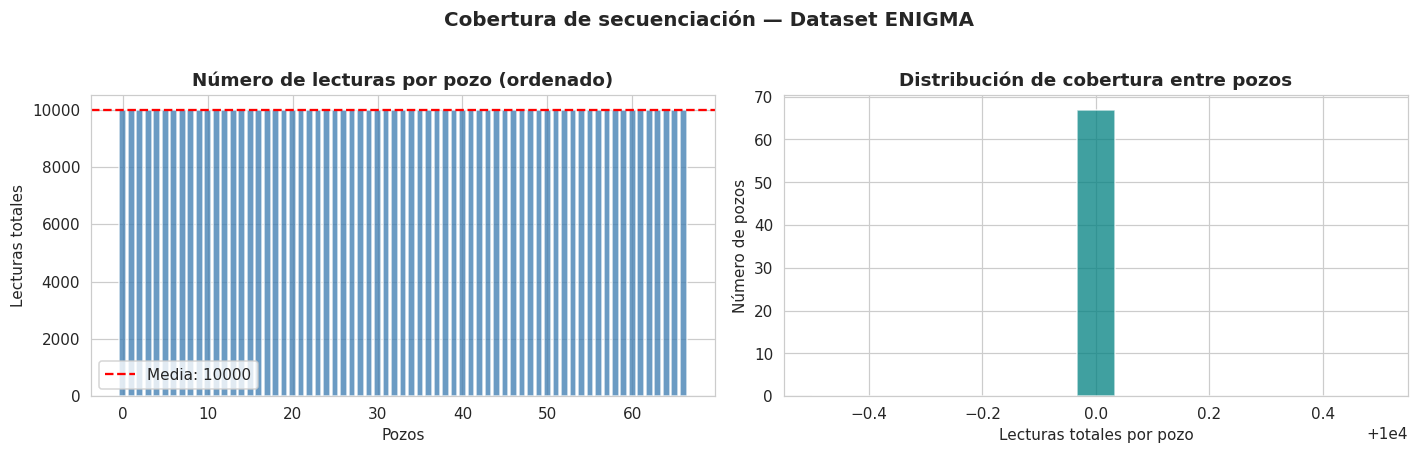

count       67.0000
mean    10,000.0000
std          0.0000
min     10,000.0000
25%     10,000.0000
50%     10,000.0000
75%     10,000.0000
max     10,000.0000
dtype: float64


In [9]:
# Lecturas totales por pozo
lecturas_por_muestra = otu_trabajo.sum(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(len(lecturas_por_muestra)), lecturas_por_muestra.values,
            color='steelblue', alpha=0.8)
axes[0].axhline(lecturas_por_muestra.mean(), color='red', linestyle='--',
                label=f'Media: {lecturas_por_muestra.mean():.0f}')
axes[0].set_title('Número de lecturas por pozo (ordenado)', fontweight='bold')
axes[0].set_xlabel('Pozos')
axes[0].set_ylabel('Lecturas totales')
axes[0].legend()

axes[1].hist(lecturas_por_muestra.values, bins=15, color='teal', alpha=0.75, edgecolor='white')
axes[1].set_title('Distribución de cobertura entre pozos', fontweight='bold')
axes[1].set_xlabel('Lecturas totales por pozo')
axes[1].set_ylabel('Número de pozos')

plt.suptitle('Cobertura de secuenciación — Dataset ENIGMA', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(lecturas_por_muestra.describe().round(1))

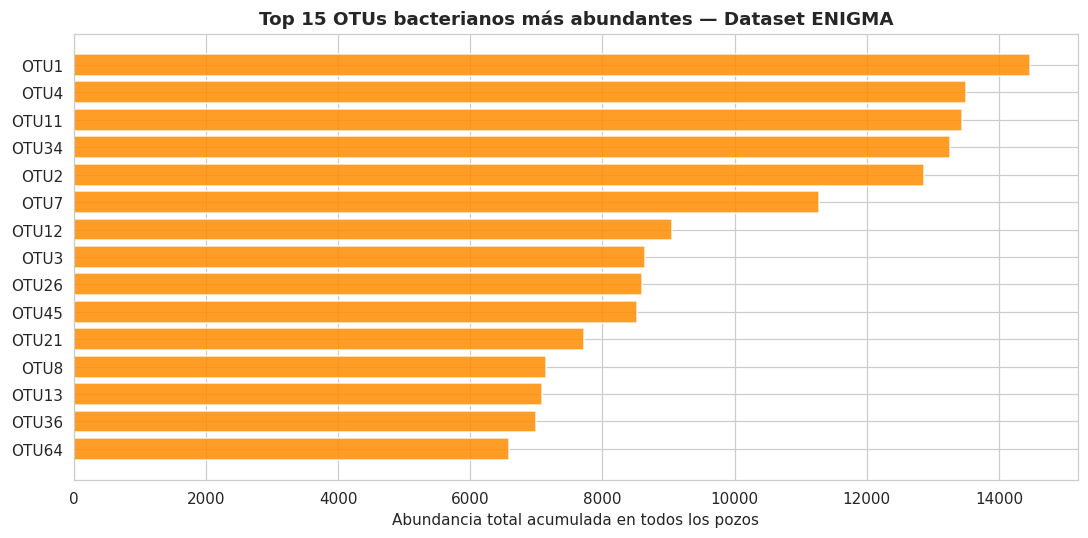

In [10]:
# Top 15 OTUs más abundantes
top_otus = otu_trabajo.sum(axis=1).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.barh(range(len(top_otus)), top_otus.values[::-1], color='darkorange', alpha=0.85)
plt.yticks(range(len(top_otus)), [str(o)[:30] for o in top_otus.index[::-1]])
plt.xlabel('Abundancia total acumulada en todos los pozos')
plt.title('Top 15 OTUs bacterianos más abundantes — Dataset ENIGMA', fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones del análisis exploratorio:**

1. La profundidad de secuenciación es **constante** entre pozos: los 67 pozos tienen exactamente 10,000 lecturas cada uno (desviación estándar = 0), porque la tabla de OTUs ya fue rarefaccionada a esa profundidad común. Esto elimina la necesidad de corregir por diferencias en esfuerzo de muestreo al comparar la riqueza entre pozos.
2. La distribución de OTUs sigue un patrón típico de comunidades microbianas: pocos OTUs concentran la mayoría de las lecturas (dominantes), mientras que la mayoría de los OTUs tienen muy baja abundancia.
3. La variabilidad entre pozos parece alta, lo que sugiere que existen factores ambientales locales que estructuran las comunidades de forma diferente entre sitios; cuáles son esos factores se explora con más detalle en la sección de correlaciones (Gráfica 4), sin asumir de antemano que se trata de pH o contaminación metálica clásica.

In [11]:
# Métricas de diversidad alfa que se calcularán
METRICAS_ALFA = ['Riqueza', 'Shannon', 'Simpson', 'Chao1']

# Variables ambientales de interés para correlación
VARS_AMBIENTALES_INTERES = ['ph', 'fe', 'mn', 'u', 'conductivity', 'temperature']

print('Configuración del proyecto:')
print('  Métricas de diversidad alfa:', METRICAS_ALFA)
print('  Variables ambientales para correlación:', VARS_AMBIENTALES_INTERES)

Configuración del proyecto:
  Métricas de diversidad alfa: ['Riqueza', 'Shannon', 'Simpson', 'Chao1']
  Variables ambientales para correlación: ['ph', 'fe', 'mn', 'u', 'conductivity', 'temperature']


## 9. Indicadores principales

| Indicador | Pregunta que responde | Cómo se calcula | Columna requerida | Valor esperado |
|---|---|---|---|---|
| Riqueza media de OTUs | ¿Cuántas bacterias hay en promedio por pozo? | Conteo de OTUs con abundancia > 0 por muestra | OTU table | ~200-500 OTUs/pozo |
| Índice de Shannon (H') | ¿Qué tan variada y equilibrada es la comunidad? | -Σ(pᵢ × ln pᵢ) | OTU table | Valores típicos: 2–5 |
| Distancia Bray-Curtis media | ¿Qué tan distintas son las comunidades entre pozos? | Disimilitud basada en abundancias relativas | OTU table | 0 = idénticas, 1 = totalmente distintas |
| Correlación Spearman (variables ambientales–Shannon) | ¿Qué variables ambientales afectan la diversidad bacteriana? | rs entre cada variable ambiental y H' | Metadatos + Shannon | Correlación significativa (p < 0.05) |
| % de varianza PC1+PC2 | ¿Cuánta información captura el PCoA? | Eigenvalores del PCoA / suma total | Distancia Bray-Curtis | >30% indica estructura clara |
| Coeficiente de variación de Shannon | ¿Qué tan homogénea o heterogénea es la diversidad entre pozos? | Desviación estándar de Shannon / media de Shannon × 100 | OTU table | Tasa relativa, sin unidad de escala fija |

### ¿Qué es una OTU y qué mide cada indicador de diversidad?

**OTU (Unidad Taxonómica Operativa, *Operational Taxonomic Unit*):** en estudios de secuenciación masiva como este (16S rRNA V4), no siempre es posible identificar la especie bacteriana exacta a partir de una secuencia corta de ADN. Por eso, las secuencias se agrupan según su similitud genética (típicamente ≥97%) en clústeres llamados OTUs, que funcionan como un sustituto operativo de "especie": dos secuencias que caen en el mismo OTU se tratan, para fines del análisis, como el mismo tipo de bacteria. La tabla de OTUs de este proyecto contiene 16,236 OTUs distintos detectados en los 67 pozos.

A partir de la abundancia de OTUs por pozo se calculan los siguientes indicadores de diversidad (alfa y beta):

| Métrica | Qué mide | Interpretación |
|---|---|---|
| Riqueza | Cantidad de OTUs distintos observados en un pozo | Un valor mayor indica más tipos de bacterias detectadas, sin considerar qué tan abundante es cada una |
| Shannon (H') | Diversidad que combina riqueza y equitatividad (qué tan repartida está la abundancia entre OTUs) | Un valor mayor indica una comunidad con más tipos de bacterias y más equilibrada entre ellas; un pozo dominado por pocos OTUs tendrá un Shannon bajo aunque tenga muchos OTUs presentes |
| Simpson (1-D) | Probabilidad de que dos bacterias tomadas al azar del mismo pozo pertenezcan a OTUs distintos | Un valor cercano a 1 indica alta diversidad/baja dominancia; un valor cercano a 0 indica que pocos OTUs dominan la comunidad |
| Chao1 | Estimador de la riqueza total, incluyendo OTUs raros (singletons/doubletons) que probablemente no se detectaron por la profundidad de muestreo | Ayuda a corregir el sesgo de subestimar la riqueza real cuando hay muchos OTUs poco abundantes |
| Bray-Curtis | Distancia de disimilitud en la composición bacteriana entre dos pozos (0 = idéntica, 1 = completamente distinta) | Una distancia mayor indica que dos pozos comparten menos OTUs, o tienen abundancias muy distintas entre los OTUs que sí comparten |
| PCoA | Técnica de ordenación que proyecta la matriz de distancias Bray-Curtis en un espacio de pocas dimensiones (2D) para poder visualizarla | Pozos que aparecen cercanos en el gráfico tienen comunidades bacterianas más similares; la cercanía es solo una aproximación visual y depende de cuánta varianza capturan los ejes graficados |

Estas métricas se calculan con la función `calcular_diversidad_alfa()` (Riqueza, Shannon, Simpson, Chao1) y con la matriz de distancias Bray-Curtis y la función `pcoa()` (diversidad beta), ambas definidas en la sección de funciones auxiliares.

In [12]:
# Cálculo de diversidad alfa
alfa = calcular_diversidad_alfa(otu_trabajo)
print('Estadísticas de diversidad alfa:')
display(alfa.describe().round(3))

Estadísticas de diversidad alfa:


,Riqueza,Shannon,Simpson,Chao1
count,67.0000,67.0000,67.0000,67.0000
mean,882.0450,4.2150,0.8840,"1,489.0070"
std,631.7930,1.5400,0.1490,"1,152.6820"
min,86.0000,0.8220,0.3590,175.7000
25%,353.5000,3.0160,0.8360,532.3500
50%,798.0000,4.5210,0.9580,"1,288.0000"
75%,"1,328.0000",5.4030,0.9790,"2,111.0000"
max,"2,971.0000",6.8380,0.9960,"5,771.0000"


In [13]:
# Resumen de indicadores principales
indicadores = [
    {'Indicador': 'Pozos analizados',             'Valor': len(
        alfa),                          'Interpretación': 'Total de muestras de agua subterránea en el análisis'},
    {'Indicador': 'OTUs totales detectados',
        'Valor': otu_trabajo.shape[0],               'Interpretación': 'Riqueza global del dataset'},
    {'Indicador': 'Riqueza media por pozo',        'Valor': round(
        alfa['Riqueza'].mean(), 1),   'Interpretación': 'Número promedio de OTUs por pozo'},
    {'Indicador': "Shannon medio (H')",            'Valor': round(alfa['Shannon'].mean(
    ), 3),   'Interpretación': 'Diversidad promedio considerando riqueza y equitatividad'},
    {'Indicador': 'Simpson medio (1-D)',            'Valor': round(alfa['Simpson'].mean(
    ), 3),   'Interpretación': 'Probabilidad promedio de que dos bacterias sean de distinta especie'},
    {'Indicador': 'Chao1 medio (riqueza estimada)', 'Valor': round(alfa['Chao1'].mean(
    ), 1),     'Interpretación': 'Estimación de riqueza incluyendo OTUs raros no detectados'},
]

resumen_indicadores = pd.DataFrame(indicadores)
display(resumen_indicadores)

,Indicador,Valor,Interpretación
0,Pozos analizados,67.0000,Total de muestras de agua subterránea en el an...
1,OTUs totales detectados,"16,236.0000",Riqueza global del dataset
2,Riqueza media por pozo,882.0000,Número promedio de OTUs por pozo
3,Shannon medio (H'),4.2150,Diversidad promedio considerando riqueza y equ...
4,Simpson medio (1-D),0.8840,Probabilidad promedio de que dos bacterias sea...
5,Chao1 medio (riqueza estimada),"1,489.0000",Estimación de riqueza incluyendo OTUs raros no...


El coeficiente de variación de Shannon, calculado a continuación, complementa estos indicadores al expresar como una tasa relativa qué tan dispersa está la diversidad bacteriana entre los 67 pozos.

In [14]:
# Coeficiente de variación de Shannon (indicador complementario de dispersión relativa)
if "alfa" in globals() and "Shannon" in alfa.columns:
    cv_shannon = alfa["Shannon"].std() / alfa["Shannon"].mean() * 100
    print(f"Coeficiente de variación de Shannon entre pozos: {cv_shannon:.2f}%")
else:
    print("Debe existir un dataframe llamado alfa con una columna Shannon.")

Coeficiente de variación de Shannon entre pozos: 36.53%


Este porcentaje indica qué tan dispersa está la diversidad Shannon entre los 67 pozos en relación con su media: un CV alto sugiere que los pozos difieren considerablemente entre sí en diversidad bacteriana, mientras que un CV bajo indicaría comunidades más homogéneas entre pozos. A diferencia de la distancia Bray-Curtis media (que es una medida absoluta y difícil de comparar entre escalas), el CV es una tasa relativa, fácil de comunicar a los gestores de monitoreo de agua subterránea.

## 10. Visualizaciones

**Gráfica 1 — Diversidad alfa por pozo**

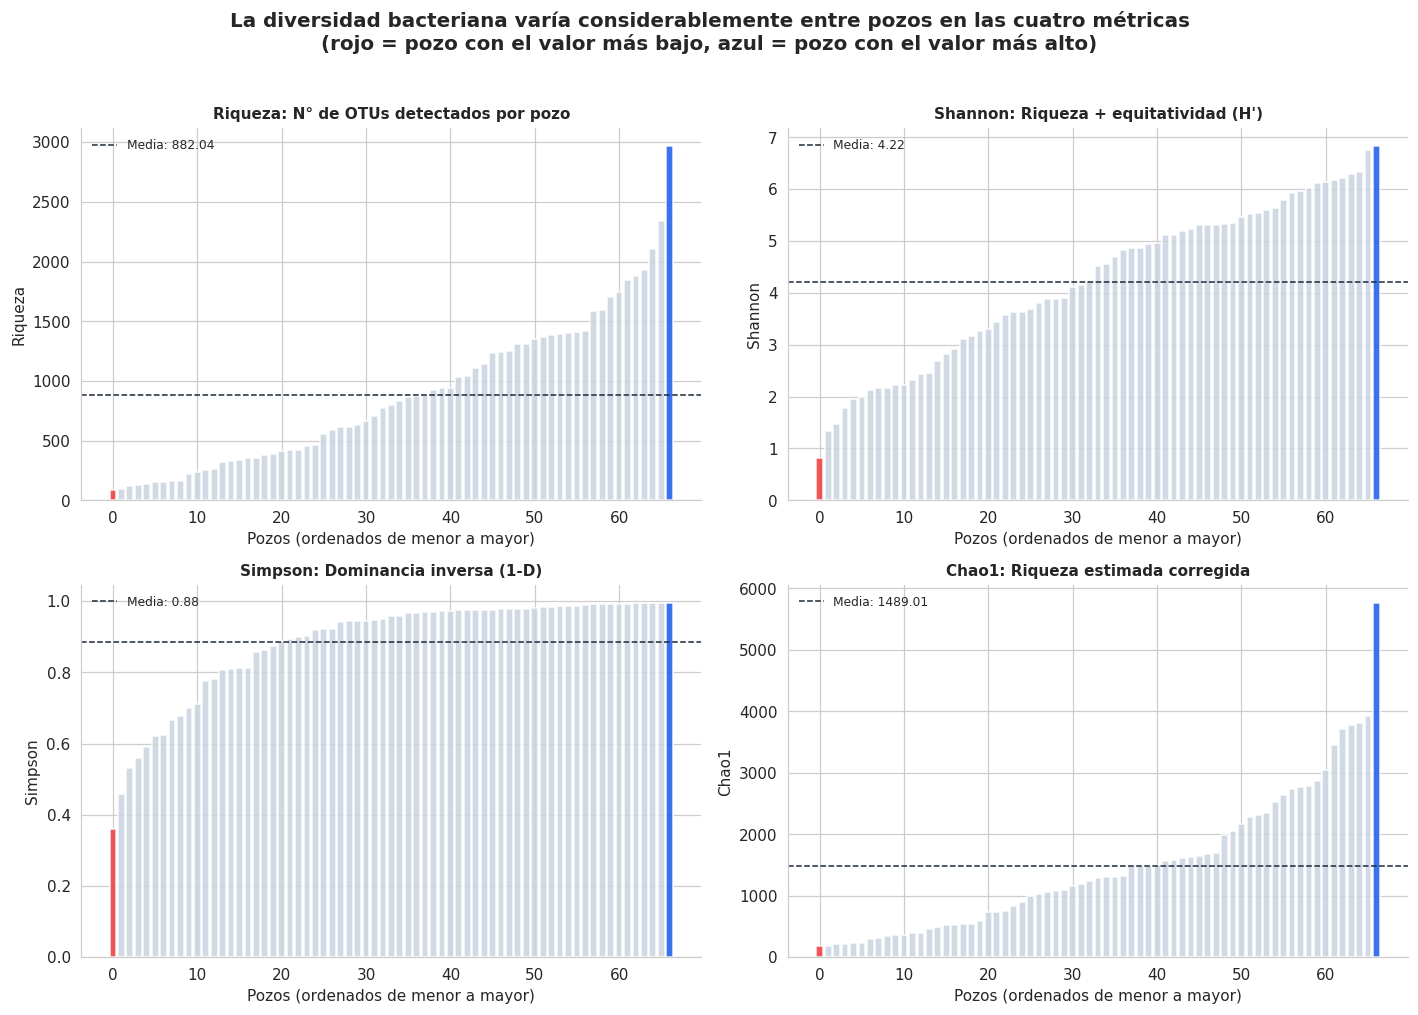

In [15]:
# GRÁFICA 1: Diversidad alfa por pozo
# Foco de color: se resalta el pozo con el valor más alto y el más bajo
# en cada métrica; el resto queda en gris para no dispersar la atención.
GRIS_BASE = '#CBD5E1'
AZUL_FOCO = '#2563EB'
ROJO_FOCO = '#EF4444'
descripciones = [
    'N° de OTUs detectados por pozo',
    "Riqueza + equitatividad (H')",
    'Dominancia inversa (1-D)',
    'Riqueza estimada corregida'
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, metrica, desc in zip(axes.flat, METRICAS_ALFA, descripciones):
    valores = alfa[metrica].sort_values()
    colores_barra = [GRIS_BASE] * len(valores)
    colores_barra[0] = ROJO_FOCO
    colores_barra[-1] = AZUL_FOCO
    ax.bar(range(len(valores)), valores.values, color=colores_barra, alpha=0.9)
    ax.axhline(valores.mean(), color='#1E293B', linestyle='--', linewidth=1,
               label=f'Media: {valores.mean():.2f}')
    ax.set_title(f'{metrica}: {desc}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Pozos (ordenados de menor a mayor)')
    ax.set_ylabel(metrica)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, frameon=False)

plt.suptitle('La diversidad bacteriana varía considerablemente entre pozos en las cuatro métricas\n'
             '(rojo = pozo con el valor más bajo, azul = pozo con el valor más alto)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

*Interpretación:* existe variabilidad considerable entre los 67 pozos en las cuatro métricas de diversidad alfa, sin un patrón uniforme; ningún pozo se comporta como un caso extremo en todas las métricas simultáneamente. Esta gráfica es la base del proyecto, ya que permite comparar los 67 pozos en las cuatro métricas y detectar valores extremos que podrían orientar el monitoreo prioritario.

**Gráfica 2 — Diversidad beta: heatmap Bray-Curtis e histograma de disimilitud**

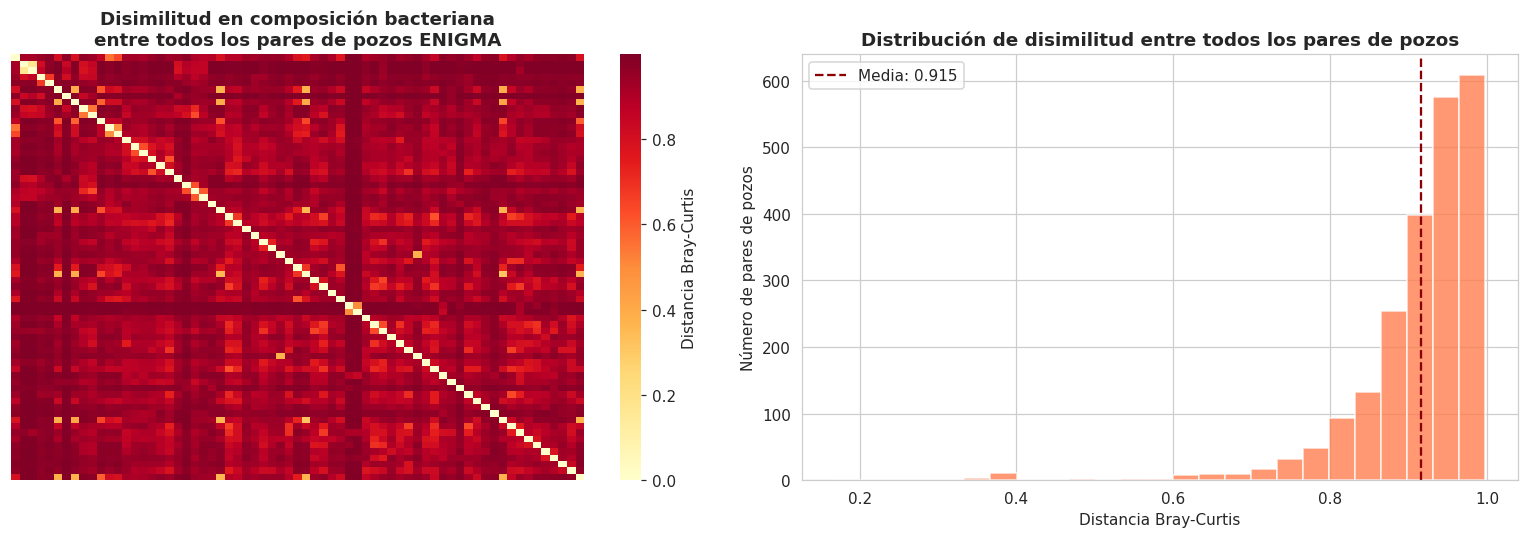

Rango Bray-Curtis: 0.167 – 0.998


In [16]:
# GRÁFICA 2: Diversidad Beta — Heatmap Bray-Curtis + histograma
otu_rel = otu_trabajo.div(otu_trabajo.sum(axis=0), axis=1)
otu_T = otu_rel.T

dist_bc = pd.DataFrame(
    cdist(otu_T.values, otu_T.values, metric='braycurtis'),
    index=otu_T.index, columns=otu_T.index
)
distancias_upper = dist_bc.values[np.triu_indices_from(dist_bc.values, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(dist_bc, cmap='YlOrRd', ax=axes[0],
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Distancia Bray-Curtis'})
axes[0].set_title('Disimilitud en composición bacteriana\nentre todos los pares de pozos ENIGMA',
                  fontweight='bold')

axes[1].hist(distancias_upper, bins=25, color='coral', alpha=0.8, edgecolor='white')
axes[1].axvline(distancias_upper.mean(), color='darkred', linestyle='--',
                label=f'Media: {distancias_upper.mean():.3f}')
axes[1].set_xlabel('Distancia Bray-Curtis')
axes[1].set_ylabel('Número de pares de pozos')
axes[1].set_title('Distribución de disimilitud entre todos los pares de pozos', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Rango Bray-Curtis: {distancias_upper.min():.3f} – {distancias_upper.max():.3f}')

*Interpretación:* la mayoría de los pares de pozos presentan disimilitud media-alta en composición bacteriana, lo que indica que las comunidades no son homogéneas entre sitios. Esta matriz de distancias es la base sobre la cual se construye la ordenación PCoA presentada a continuación.

**Gráfica 3 — PCoA: ordenación de comunidades en 2D**

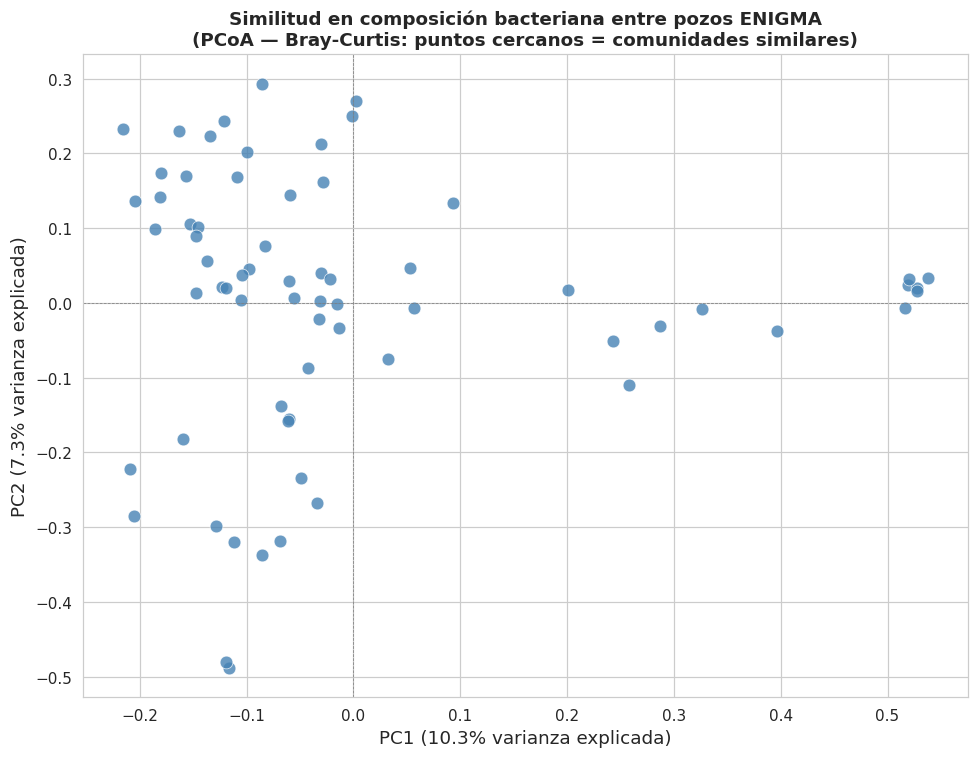

PC1: 10.3% | PC2: 7.3% de varianza explicada


In [17]:
# GRÁFICA 3: PCoA — Ordenación de comunidades en 2D
coords, var_exp = pcoa(dist_bc)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords[:, 0], coords[:, 1], s=70, color='steelblue',
           alpha=0.8, edgecolors='white', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% varianza explicada)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% varianza explicada)', fontsize=12)
ax.set_title('Similitud en composición bacteriana entre pozos ENIGMA\n'
             '(PCoA — Bray-Curtis: puntos cercanos = comunidades similares)',
             fontweight='bold', fontsize=12)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()
print(f'PC1: {var_exp[0]:.1f}% | PC2: {var_exp[1]:.1f}% de varianza explicada')

**Interpretación:** los dos primeros componentes del PCoA explican conjuntamente solo 17.6% de la variabilidad total en la composición bacteriana entre pozos (PC1: 10.3%, PC2: 7.3%, ver impresión arriba). Esto significa que más del 80% de la variación entre comunidades no se refleja en este gráfico 2D. La cercanía o lejanía visual entre pozos es, por tanto, una aproximación parcial y **no debe interpretarse como evidencia de grupos (clusters) claramente definidos**; para confirmar la existencia de agrupaciones reales se necesitaría un análisis complementario, como clustering jerárquico o una prueba PERMANOVA.

**Gráfica 4 — Correlación de variables ambientales con Shannon**

,Variable ambiental,rs (Spearman),p-value,n
2,al_mgl,-0.3470,0.0070,59
14,cd_mgl,-0.3440,0.0044,67
30,k_mgl,-0.3330,0.0059,67
21,cu_mgl,-0.3090,0.0110,67
32,li_mgl,-0.3020,0.0129,67
0,aodc_cellsml,-0.2940,0.0184,64
10,br_mgl,-0.2900,0.1422,27
39,na_mgl,-0.2900,0.0173,67
25,depth,-0.2870,0.0187,67
51,top_depth,-0.2840,0.0201,67


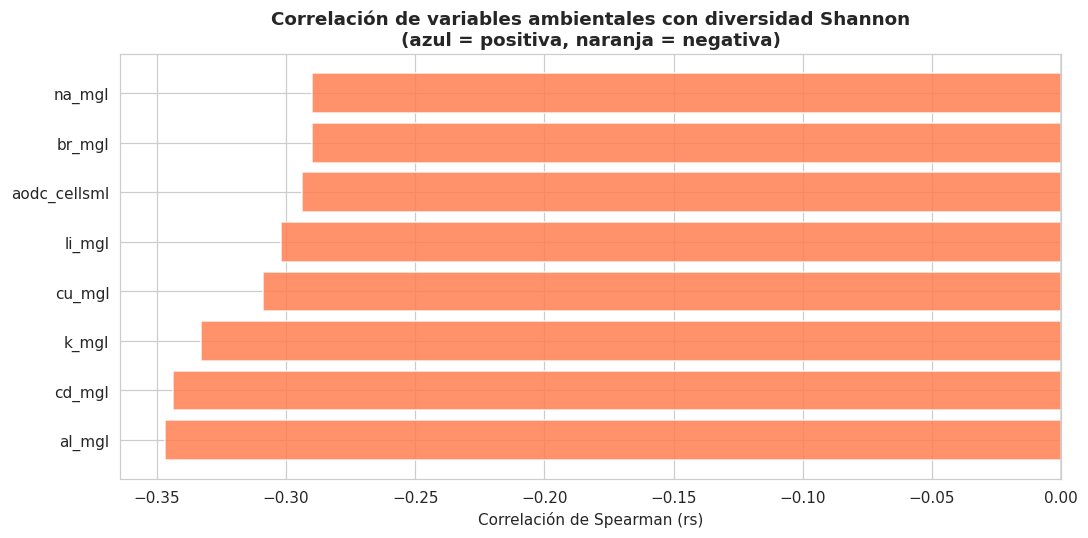

In [18]:
# GRÁFICA 4: Correlación de variables ambientales con Shannon
df_analisis = alfa.join(meta_trabajo, how='inner')
vars_numericas = df_analisis.select_dtypes(include=[np.number]).columns.tolist()
vars_meta_num = [v for v in vars_numericas if v not in METRICAS_ALFA]

# Calcular correlaciones Spearman
correlaciones = []
for var in vars_meta_num:
    datos_pares = df_analisis[['Shannon', var]].dropna()
    if len(datos_pares) > 5:
        rs, p = spearmanr(datos_pares['Shannon'], datos_pares[var])
        correlaciones.append({'Variable ambiental': var, 'rs (Spearman)': round(
            rs, 3), 'p-value': round(p, 4), 'n': len(datos_pares)})

df_corr = pd.DataFrame(correlaciones).sort_values('rs (Spearman)', key=abs, ascending=False)
display(df_corr.head(10))

# Graficar las 8 correlaciones más fuertes
top_vars = df_corr.head(8)
colores_barras = ['steelblue' if r > 0 else 'coral' for r in top_vars['rs (Spearman)']]

plt.figure(figsize=(10, 5))
plt.barh(top_vars['Variable ambiental'], top_vars['rs (Spearman)'],
         color=colores_barras, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlación de Spearman (rs)')
plt.title('Correlación de variables ambientales con diversidad Shannon\n(azul = positiva, naranja = negativa)', fontweight='bold')
plt.tight_layout()
plt.show()

*Interpretación:* las correlaciones más fuertes con Shannon no corresponden a las variables originalmente hipotetizadas (pH, Fe, Mn, U), sino a aluminio, cadmio, potasio, cobre, litio, sodio y profundidad, lo que sugiere que el monitoreo debe ampliarse más allá de los metales clásicamente asociados a contaminación. Esta gráfica responde directamente al objetivo de evaluar si las variables ambientales se relacionan con la diversidad bacteriana, conectando los datos ecológicos con variables ambientales para apoyar decisiones de monitoreo.

## 11. Análisis avanzado

Este proyecto es de naturaleza descriptiva y correlacional: no se construyó un modelo predictivo (p. ej. de machine learning) sobre la diversidad bacteriana. El componente analítico más avanzado es la ordenación por PCoA (diversidad beta) sobre la matriz de distancias Bray-Curtis, y las correlaciones de Spearman entre variables ambientales y el índice de Shannon, ambas presentadas en la sección de visualizaciones. Un modelo predictivo (por ejemplo, para estimar Shannon a partir de variables ambientales) queda como línea de trabajo futuro, según se detalla en las recomendaciones.

## 12. Hallazgos principales

1. Existe variabilidad considerable entre los 67 pozos en las cuatro métricas de diversidad alfa (Riqueza, Shannon, Simpson, Chao1); esta variabilidad no se explica por diferencias en la profundidad de secuenciación, ya que todos los pozos fueron rarefaccionados a 10,000 lecturas.
2. El PCoA muestra cierta separación visual entre pozos según su composición bacteriana, pero los dos primeros componentes explican solo el 17.6% de la variabilidad total (PC1: 10.3%, PC2: 7.3%), por lo que esta observación es preliminar.
3. Las variables ambientales con mayor asociación (negativa, moderada) con la diversidad Shannon son aluminio, cadmio, potasio, cobre, litio, sodio y la profundidad del pozo (rs entre -0.28 y -0.35, p<0.05), distintas a las originalmente hipotetizadas (pH, Fe, Mn, U).
4. Varias variables ambientales, en particular `po4_mgl` (83.6% faltante) y `br_mgl` (59.7% faltante), tienen un porcentaje alto de datos faltantes, lo que reduce el tamaño de muestra disponible para esas correlaciones y limita la confiabilidad de cualquier conclusión sobre ellas.

## 13. Limitaciones

- El bajo porcentaje de varianza explicada por el PCoA (17.6% entre PC1 y PC2) limita la capacidad de identificar grupos discretos de pozos a partir de la sola inspección visual; un análisis de clustering jerárquico o una prueba estadística como PERMANOVA sería necesario para confirmar la existencia de agrupaciones reales.
- Trece variables ambientales presentan datos faltantes, con casos extremos como `po4_mgl` (83.6%) y `br_mgl` (59.7%); las correlaciones que involucran estas variables se basan en un número de pozos (n) considerablemente menor a 67, lo que reduce su poder estadístico.
- El análisis realizado es principalmente descriptivo y correlacional, por lo que no permite afirmar causalidad entre las variables ambientales y la diversidad bacteriana observada.
- El dataset corresponde a un muestreo puntual de 67 pozos; no incluye series de tiempo que permitan detectar cambios estacionales en la comunidad bacteriana, ni coordenadas geográficas que permitan un análisis espacial explícito.

## 14. Recomendaciones

Debido a que las correlaciones de Spearman muestran asociación significativa entre la diversidad Shannon y aluminio, cadmio, potasio, cobre, litio, sodio y profundidad del pozo, se recomienda ampliar el panel de monitoreo ambiental de estos pozos para incluir explícitamente estas variables, en lugar de limitarse únicamente a pH y a los metales clásicamente asociados a contaminación (Fe, Mn, U).

Se recomienda además priorizar el monitoreo continuo de los pozos ubicados en los extremos del gradiente de diversidad (los de mayor y menor Shannon), dado que son los que mostrarían primero cambios relevantes en la comunidad bacteriana ante alteraciones ambientales.

Por último, se recomienda complementar este análisis exploratorio con un análisis de clustering jerárquico o una prueba PERMANOVA antes de tomar decisiones de manejo basadas únicamente en la separación visual observada en el PCoA, y mejorar a futuro la captura de variables con alto porcentaje de datos faltantes (`po4_mgl`, `br_mgl`) para fortalecer la confiabilidad de las correlaciones que las involucran.

## 15. Conclusiones

**Conclusión 1**

- *Resultado:* los 67 pozos presentan variabilidad considerable en las cuatro métricas de diversidad alfa (Riqueza, Shannon, Simpson, Chao1).
- *Interpretación:* esta heterogeneidad refleja diferencias reales en la estructura de las comunidades bacterianas entre pozos, y no un artefacto del esfuerzo de muestreo, ya que la profundidad de secuenciación es constante (10,000 lecturas por pozo).
- *Precaución:* la variabilidad observada no permite, por sí sola, identificar qué factor ambiental específico la origina; ese vínculo se explora en la conclusión 3.

**Conclusión 2**

- *Resultado:* el PCoA (Análisis de Coordenadas Principales) muestra cierta separación visual entre pozos según su composición bacteriana, pero los dos primeros componentes explican solo 17.6% de la variabilidad total.
- *Interpretación:* esta separación visual es una aproximación parcial y preliminar de las diferencias reales en composición bacteriana entre pozos.
- *Precaución:* no constituye evidencia de grupos (clusters) claramente definidos; se requeriría un análisis complementario (clustering jerárquico o PERMANOVA) para confirmar agrupaciones reales.

**Conclusión 3**

- *Resultado:* las correlaciones de Spearman muestran asociación negativa moderada entre Shannon y aluminio, cadmio, potasio, cobre, litio, sodio y profundidad del pozo (rs entre -0.28 y -0.35, p<0.05), distintas a las variables originalmente hipotetizadas (pH, Fe, Mn, U).
- *Interpretación:* el monitoreo de la diversidad bacteriana en estos pozos debería ampliarse más allá de los metales clásicamente asociados a contaminación, incorporando estas variables con asociación estadística más fuerte.
- *Precaución:* estos resultados describen asociaciones estadísticas, no relaciones causales; no es posible afirmar que estas variables determinen o causen los niveles de diversidad observados, y algunas de ellas (como `br_mgl`) tienen un porcentaje alto de datos faltantes que reduce la confiabilidad de la correlación correspondiente.

## 16. Resumen ejecutivo

**1. Presentación.** El proyecto se titula *Análisis de diversidad microbiana en ecosistemas de agua subterránea*.

**2. Problema.** El problema que analicé fue la falta de un análisis claro y reproducible que identifique qué variables ambientales explican la diversidad bacteriana entre los pozos de agua subterránea del estudio ENIGMA.

**3. Dataset.** Utilicé un conjunto de datos con 67 pozos (muestras) y 16,236 OTUs bacterianos, junto con más de 30 variables ambientales por pozo. Las variables más importantes fueron aluminio, cadmio, potasio, cobre, litio, sodio y profundidad del pozo.

**4. Pregunta analítica.** La pregunta que orientó mi análisis fue: ¿qué variables ambientales se asocian más fuertemente con la diversidad bacteriana (Shannon) entre los 67 pozos?

**5. Indicadores.** Los principales indicadores calculados fueron el índice de Shannon, la distancia Bray-Curtis media y el coeficiente de variación de Shannon.

**6. Resultados.** Los principales resultados fueron la variabilidad considerable en diversidad alfa entre pozos, la separación preliminar del PCoA (17.6% de varianza explicada) y la asociación de Shannon con aluminio, cadmio, potasio, cobre, litio, sodio y profundidad.

**7. Limitaciones.** Una limitación importante del análisis es el bajo porcentaje de varianza explicada por el PCoA, que impide afirmar agrupaciones claras de pozos sin un análisis estadístico complementario.

**8. Recomendaciones.** Con base en los resultados, recomiendo ampliar el panel de monitoreo ambiental de los pozos para incluir aluminio, cadmio, potasio, cobre, litio, sodio y profundidad, y priorizar el monitoreo de los pozos en los extremos del gradiente de diversidad.

**9. Cierre.** En conclusión, este proyecto permitió convertir datos crudos de secuenciación en indicadores, visualizaciones y correlaciones estadísticas reproducibles que orientan el monitoreo de la diversidad microbiana en pozos de agua subterránea, interpretando los hallazgos como asociaciones y no como relaciones causales.

## 17. Registro de revisión y control de calidad

**Proyecto:** Diversidad microbiana en pozos de agua subterránea (estudio ENIGMA)

**Cambios aplicados en la revisión final:**

1. Se explicó qué es una OTU y se agregó una tabla de interpretación de Riqueza, Shannon, Simpson, Chao1, Bray-Curtis y PCoA.
2. Se corrigió la afirmación sobre profundidad de secuenciación: los 67 pozos tienen 10,000 lecturas constantes (tabla rarefaccionada), no variables.
3. Se agregó una interpretación cautelosa del PCoA, aclarando que el 17.6% de varianza explicada no permite afirmar grupos definidos.
4. Se reportó e interpretó la magnitud de los valores faltantes en variables ambientales (`po4_mgl` 83.6%, `br_mgl` 59.7%, gases disueltos 19.4%), conectándolo con la confiabilidad de las correlaciones.
5. Se reescribió la narrativa y las conclusiones usando lenguaje de asociación (no causal), reportando las variables realmente asociadas con Shannon (aluminio, cadmio, potasio, cobre, litio, sodio y profundidad).
6. Se calculó el coeficiente de variación de Shannon entre pozos como indicador complementario.
7. Se reorganizó el notebook completo bajo una estructura final (introducción, problema, objetivos, dataset, indicadores, visualizaciones, hallazgos, limitaciones, recomendaciones, conclusiones).

**Error más importante corregido:** la afirmación de que la cobertura de secuenciación variaba entre pozos, cuando en realidad es constante (10,000 lecturas) por tratarse de una tabla rarefaccionada.

**Indicador incorporado:** el coeficiente de variación de Shannon como complemento a la distancia Bray-Curtis media, al ser una tasa relativa más fácil de comunicar a los gestores de monitoreo.

**Visualización mejorada:** el gráfico de PCoA, agregando una interpretación cautelosa sobre el porcentaje de varianza explicada.

**Conclusión actualizada:** sobre agrupaciones de pozos en el PCoA y las variables ambientales asociadas a la diversidad, reemplazando lenguaje causal e hipótesis iniciales (pH, Fe, Mn, U) por lenguaje de asociación y las variables con soporte estadístico real (aluminio, cadmio, potasio, cobre, litio, sodio y profundidad).

In [19]:
# Exportación opcional de resultados
# Descomenta las líneas que necesites para guardar los archivos:
# resumen_indicadores.to_csv('resumen_indicadores_ENIGMA.csv', index=False, encoding='utf-8-sig')
# alfa.to_csv('diversidad_alfa_ENIGMA.csv', encoding='utf-8-sig')
# dist_bc.to_csv('bray_curtis_ENIGMA.csv', encoding='utf-8-sig')

print('Notebook completo — resultados listos para exportar.')

Notebook completo — resultados listos para exportar.
